In [1]:
import sys
import os
import numpy as np
import pandas as pd
# import matplotlib.pyplot as plt

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

def unpickle(file):
    import pickle
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

def create_image(label_index, batch):
    img1red = batch[b'data'][label_index][0:1024].reshape(32,32)
    img1green = batch[b'data'][label_index][1024:2048].reshape(32,32)
    img1blue = batch[b'data'][label_index][2048:3072].reshape(32,32)
    img1 = np.dstack((img1red, img1green, img1blue))
    return img1

    

In [ ]:
batch1 = unpickle("../data/cifar-10-batches-py/test_batch")

# Generating the labels
labels = np.array(batch1[b'labels'])

# Creating a list to store the indices for each unique label
label_indices = [[] for _ in range(len(np.unique(labels)))]

# Populating the list with sampled indices
for i in np.unique(labels):
    label_indices[i] = np.random.choice(np.where(labels == i)[0], 10, replace=False).tolist()



/var/folders/2t/c8n8t7mj7xv62mh_p5b0h93w0000gn/T/ipykernel_71734/2566854217.py:14: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict = pickle.load(fo, encoding='bytes')


In [ ]:
print(batch1)

In [4]:
print(batch1)

{b'batch_label': b'testing batch 1 of 1', b'labels': [3, 8, 8, 0, 6, 6, 1, 6, 3, 1, 0, 9, 5, 7, 9, 8, 5, 7, 8, 6, 7, 0, 4, 9, 5, 2, 4, 0, 9, 6, 6, 5, 4, 5, 9, 2, 4, 1, 9, 5, 4, 6, 5, 6, 0, 9, 3, 9, 7, 6, 9, 8, 0, 3, 8, 8, 7, 7, 4, 6, 7, 3, 6, 3, 6, 2, 1, 2, 3, 7, 2, 6, 8, 8, 0, 2, 9, 3, 3, 8, 8, 1, 1, 7, 2, 5, 2, 7, 8, 9, 0, 3, 8, 6, 4, 6, 6, 0, 0, 7, 4, 5, 6, 3, 1, 1, 3, 6, 8, 7, 4, 0, 6, 2, 1, 3, 0, 4, 2, 7, 8, 3, 1, 2, 8, 0, 8, 3, 5, 2, 4, 1, 8, 9, 1, 2, 9, 7, 2, 9, 6, 5, 6, 3, 8, 7, 6, 2, 5, 2, 8, 9, 6, 0, 0, 5, 2, 9, 5, 4, 2, 1, 6, 6, 8, 4, 8, 4, 5, 0, 9, 9, 9, 8, 9, 9, 3, 7, 5, 0, 0, 5, 2, 2, 3, 8, 6, 3, 4, 0, 5, 8, 0, 1, 7, 2, 8, 8, 7, 8, 5, 1, 8, 7, 1, 3, 0, 5, 7, 9, 7, 4, 5, 9, 8, 0, 7, 9, 8, 2, 7, 6, 9, 4, 3, 9, 6, 4, 7, 6, 5, 1, 5, 8, 8, 0, 4, 0, 5, 5, 1, 1, 8, 9, 0, 3, 1, 9, 2, 2, 5, 3, 9, 9, 4, 0, 3, 0, 0, 9, 8, 1, 5, 7, 0, 8, 2, 4, 7, 0, 2, 3, 6, 3, 8, 5, 0, 3, 4, 3, 9, 0, 6, 1, 0, 9, 1, 0, 7, 9, 1, 2, 6, 9, 3, 4, 6, 0, 0, 6, 6, 6, 3, 2, 6, 1, 8, 2, 1, 6, 8, 6, 8, 0, 4, 0

In [ ]:
bachtes_meta = unpickle("../data/cifar-10-batches-py/batches.meta")
labels = np.array(bachtes_meta[b'label_names'])

{b'num_cases_per_batch': 10000, b'label_names': [b'airplane', b'automobile', b'bird', b'cat', b'deer', b'dog', b'frog', b'horse', b'ship', b'truck'], b'num_vis': 3072}


**data** - a 10000x3072 numpy array of uint8s. Each row of the array stores a 32x32 colour image. The first 1024 entries contain the red channel values, the next 1024 the green, and the final 1024 the blue. The image is stored in row-major order, so that the first 32 entries of the array are the red channel values of the first row of the image.

In [5]:
for i in range(10):
    for j in range(10):
        image = create_image(label_indices[i][j], batch1)
        plt.imsave('../figs/cifar_images_examples/' + str(labels[i]) + '_' + str(j) + '.png', image)

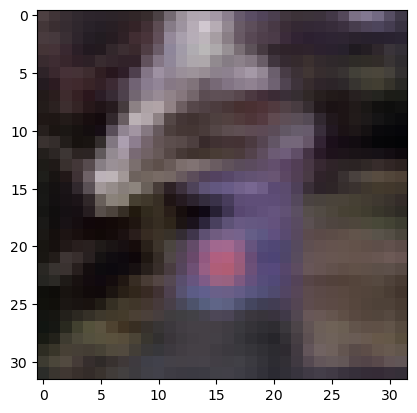

In [19]:
image = create_image(6024, batch1)
plt.imshow(image)
plt.imsave('../figs/cifar_images_examples/' + "ambiguous_image1" + '.png', image)

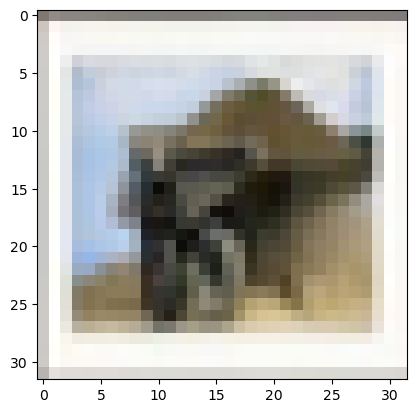

In [17]:
image = create_image(1924, batch1)
plt.imshow(image)
plt.imsave('../figs/cifar_images_examples/' + "ambiguous_image2" + '.png', image)

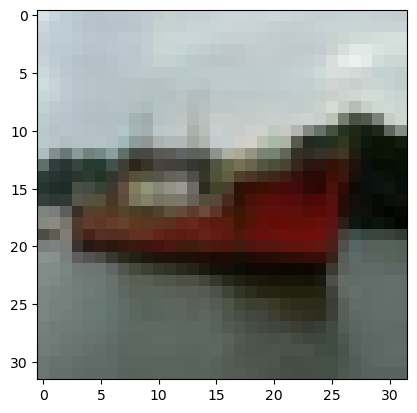

In [18]:
image = create_image(404, batch1)
plt.imshow(image)
plt.imsave('../figs/cifar_images_examples/' + "unambiguous_image" + '.png', image)

/var/folders/2t/c8n8t7mj7xv62mh_p5b0h93w0000gn/T/ipykernel_17213/4210761680.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  image = create_image(entropy_indices['index'][i], batch1)


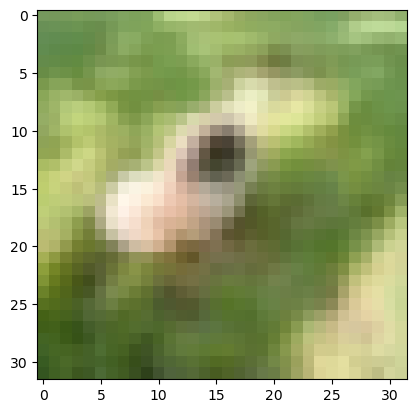

In [7]:
entropy_indices = pd.read_csv('../data/top10_entropy.csv', index_col=0)

for i in range(10):
    image = create_image(entropy_indices['index'][i], batch1)
    plt.imshow(image)
    plt.imsave('../figs/cifar_images_examples/' + "entropy_" + str(i) + '.png', image)
    

/var/folders/2t/c8n8t7mj7xv62mh_p5b0h93w0000gn/T/ipykernel_24168/3753617063.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  image = create_image(entropy_indices['index'][i], batch1)


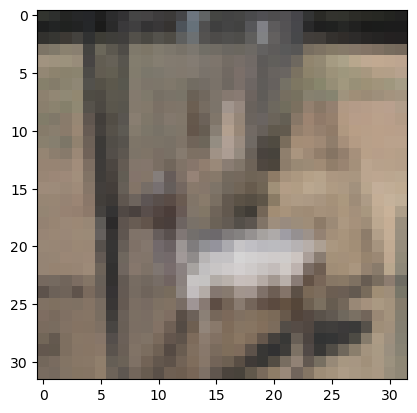

In [5]:
entropy_indices = pd.read_csv('../data/special_entropy.csv', index_col=0)

for i in range(2):
    image = create_image(entropy_indices['index'][i], batch1)
    plt.imshow(image)
    plt.imsave('../figs/cifar_images_examples/' + "special_entropy_" + str(i) + '.png', image)
    